In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
os.getcwd()

'/home/matei/Financial-Fraud-Detection/notebooks/OnlinePurchasing'

In [3]:
path_to_dataset = '../../data/raw/online_shoppers_intention_recoded.csv'

if not os.path.isfile(path_to_dataset):
    print("no good")
else:
    df = pd.read_csv(path_to_dataset)

In [4]:
df.shape

(12330, 18)

In [5]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(125)

In [7]:
df = df.drop_duplicates()
df.shape[0]

12205

In [8]:
num_cols = ['Administrative', 'Administrative_Duration',
            'Informational', 'Informational_Duration',
            'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

In [9]:
outlier_report = {}
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'Lower': lower, 'Upper': upper,
                           'N_outliers': n_out, 'Pct': pct}
    print(f"  {col:<28} {Q1:>8.3f} {Q3:>8.3f} {IQR:>8.3f} {lower:>12.3f} {upper:>12.3f} {n_out:>10,} {pct:>5.1f}%")

  Administrative                  0.000    4.000    4.000       -6.000       10.000        404   3.3%
  Administrative_Duration         0.000   94.700   94.700     -142.050      236.750      1,149   9.4%
  Informational                   0.000    0.000    0.000        0.000        0.000      2,631  21.6%
  Informational_Duration          0.000    0.000    0.000        0.000        0.000      2,405  19.7%
  ProductRelated                  8.000   38.000   30.000      -37.000       83.000      1,007   8.3%
  ProductRelated_Duration       193.000 1477.155 1284.155    -1733.232     3403.387        951   7.8%
  BounceRates                     0.000    0.017    0.017       -0.025        0.042      1,428  11.7%
  ExitRates                       0.014    0.049    0.034       -0.037        0.100      1,325  10.9%
  PageValues                      0.000    0.000    0.000        0.000        0.000      2,730  22.4%
  SpecialDay                      0.000    0.000    0.000        0.000        0.00

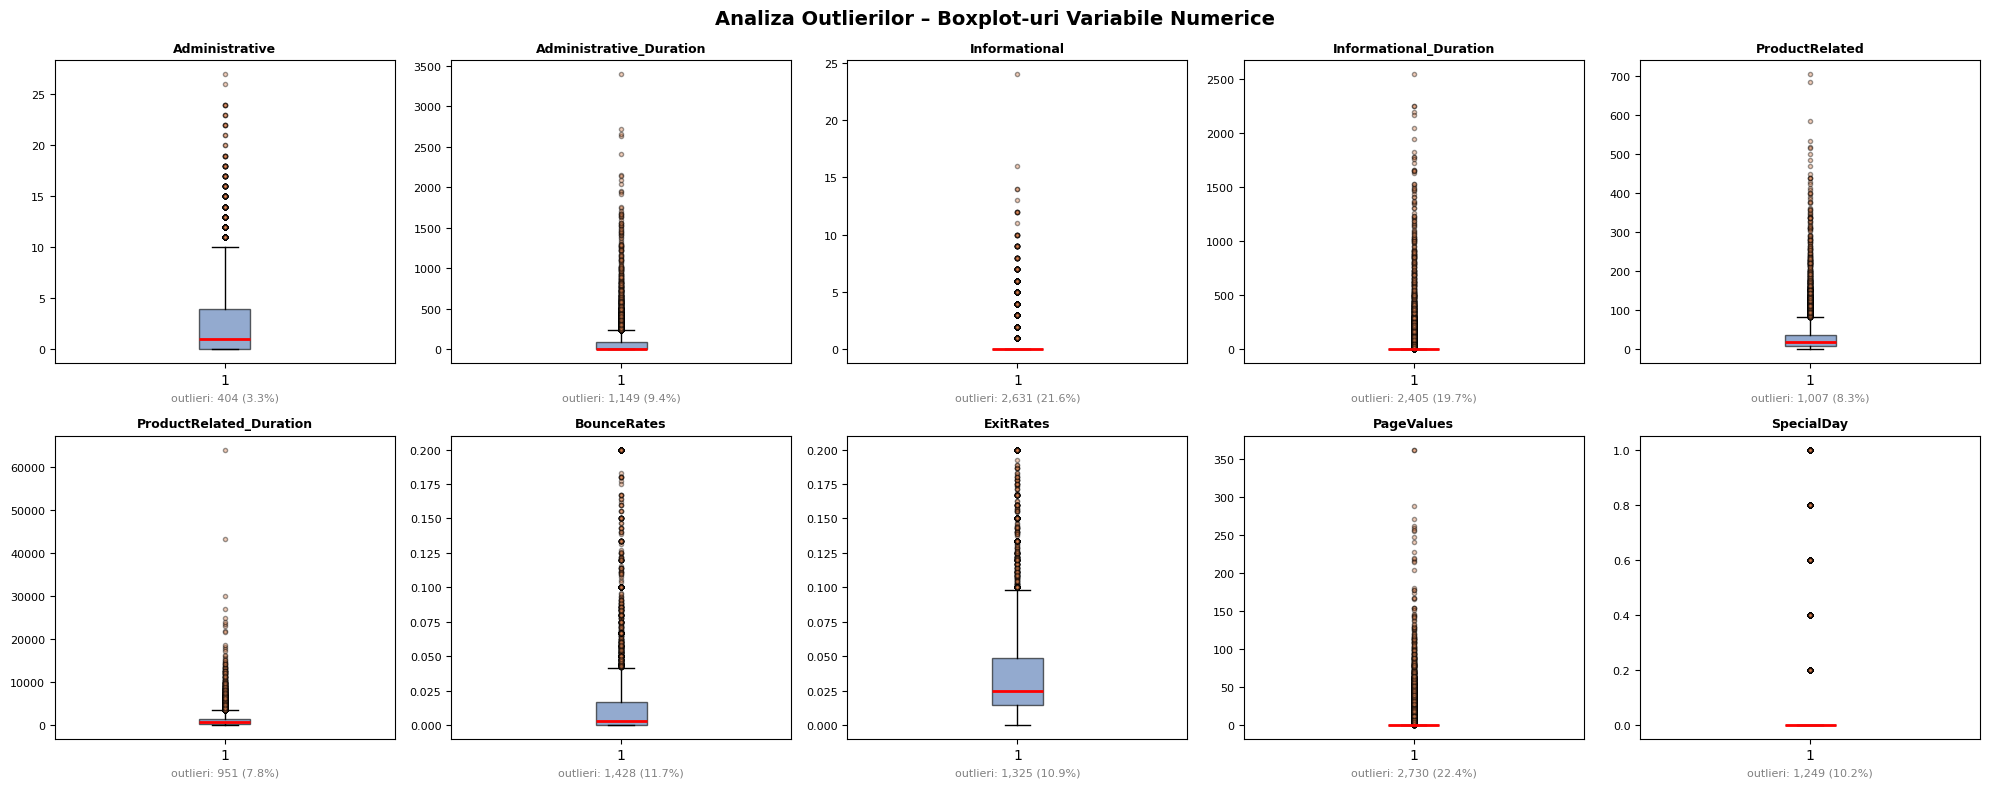

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Analiza Outlierilor – Boxplot-uri Variabile Numerice', fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#DD8452', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=8)
    n_out = outlier_report[col]['N_outliers']
    pct   = outlier_report[col]['Pct']
    axes[i].set_xlabel(f'outlieri: {n_out:,} ({pct:.1f}%)', fontsize=8, color='gray')
 
plt.tight_layout()
plt.show()

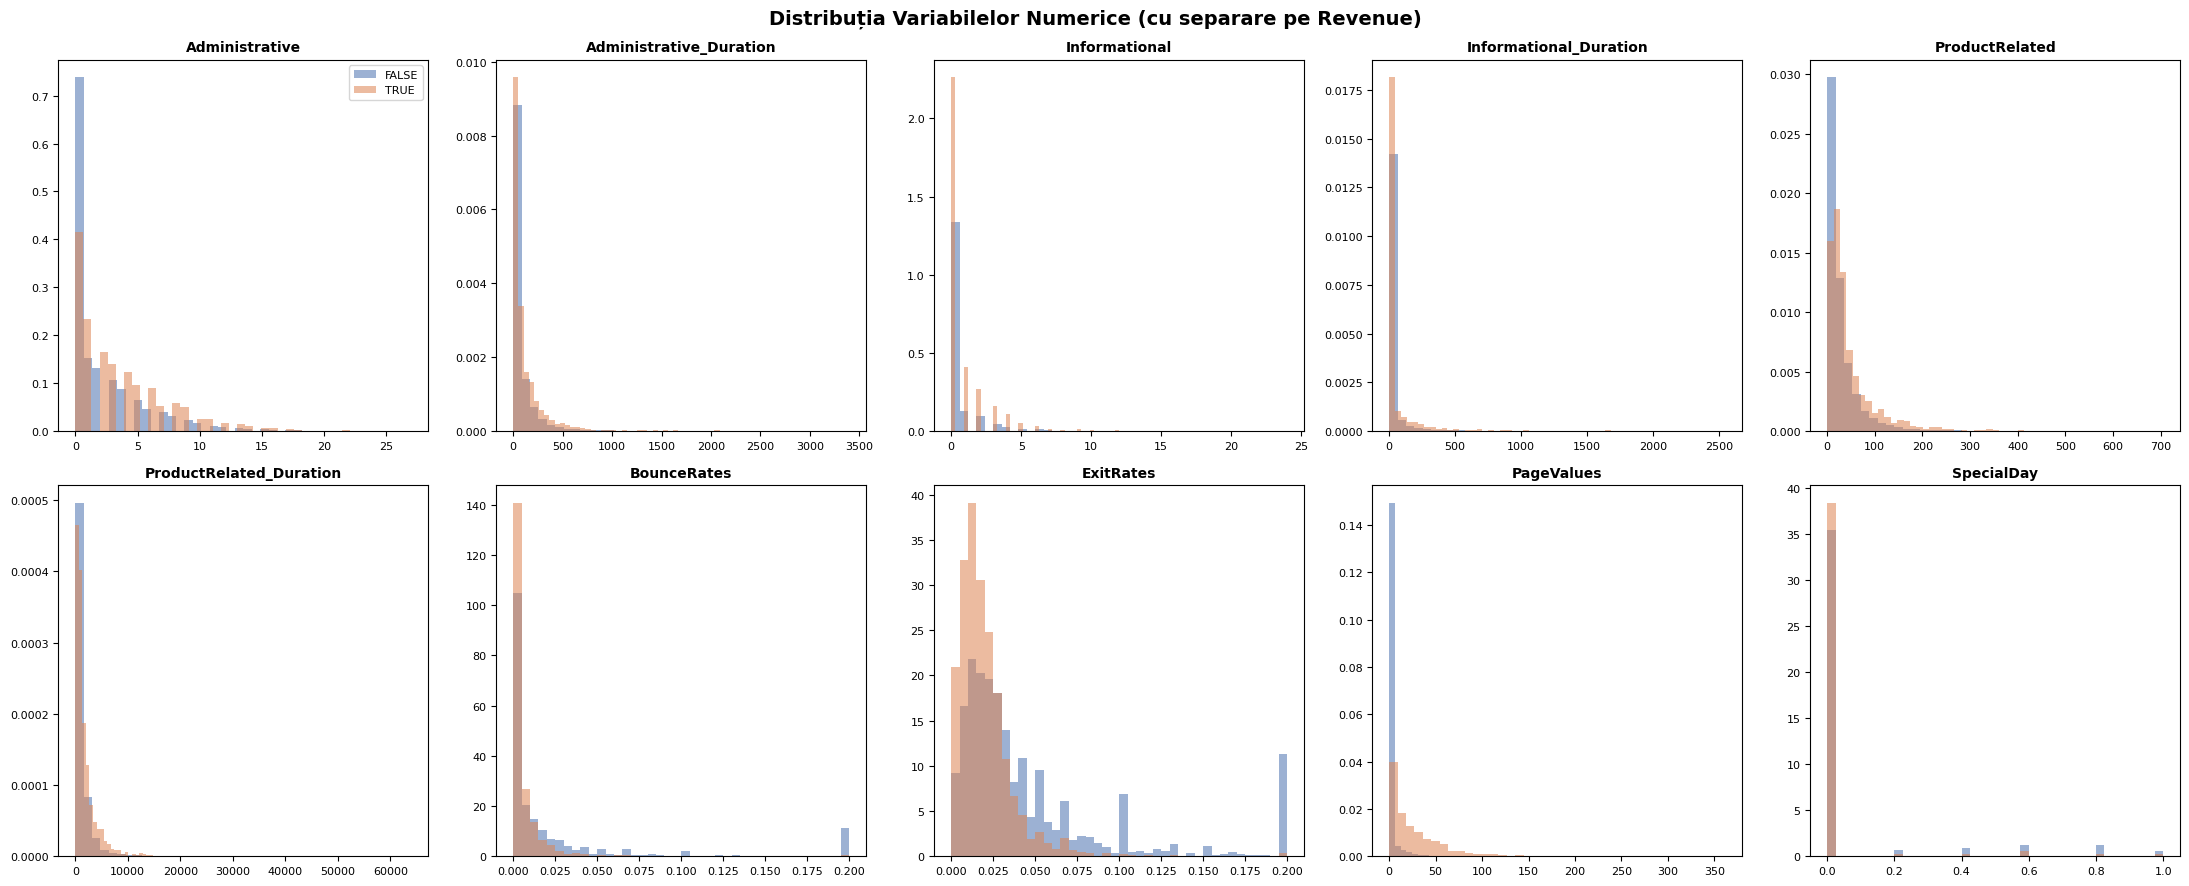

In [11]:
 
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Distribuția Variabilelor Numerice (cu separare pe Revenue)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(num_cols):
    ax = axes[i]
    for val, color, label in [(False, '#4C72B0', 'FALSE'), (True, '#DD8452', 'TRUE')]:
        data = df[df['Revenue'] == val][col]
        ax.hist(data, bins=40, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)
 
plt.tight_layout()
plt.show()

In [12]:
cat_cols = ['Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType']

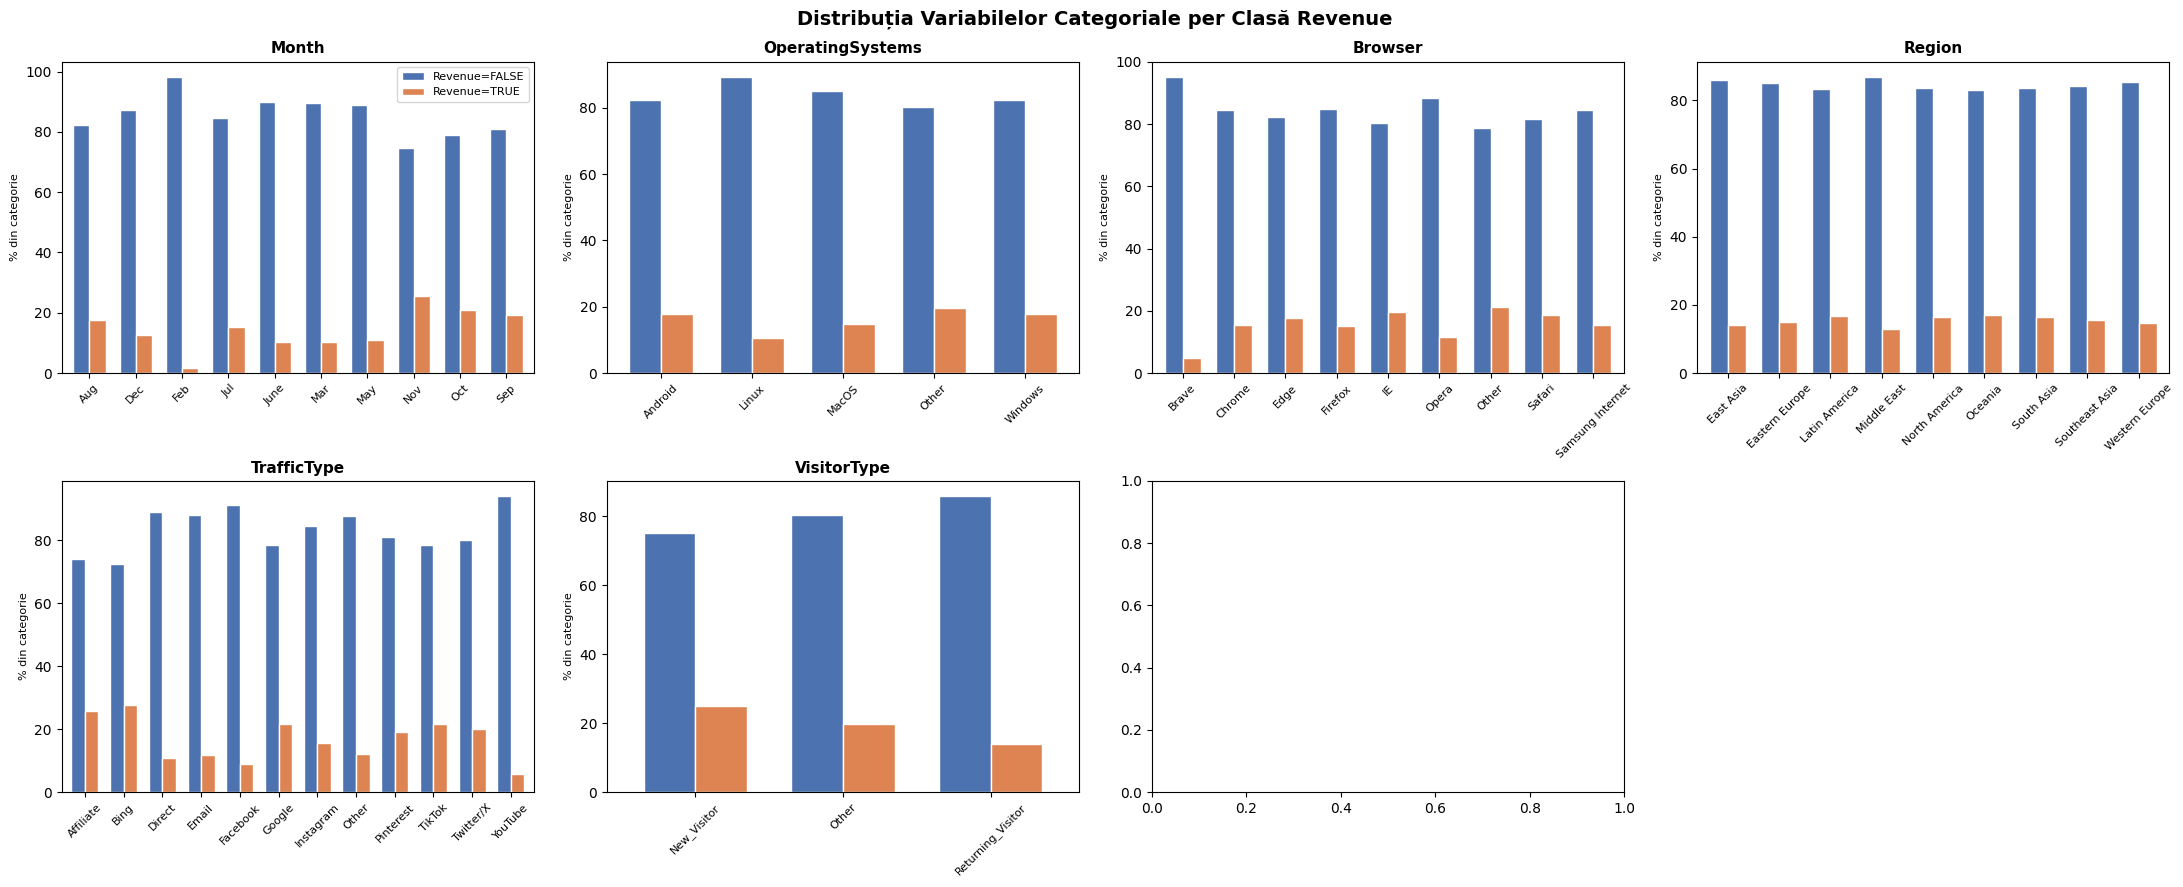

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Distribuția Variabilelor Categoriale per Clasă Revenue',
             fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['Revenue'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white',
            width=0.7, legend=(i == 0))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% din categorie', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    if i == 0:
        ax.legend(['Revenue=FALSE', 'Revenue=TRUE'], fontsize=8)
 
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

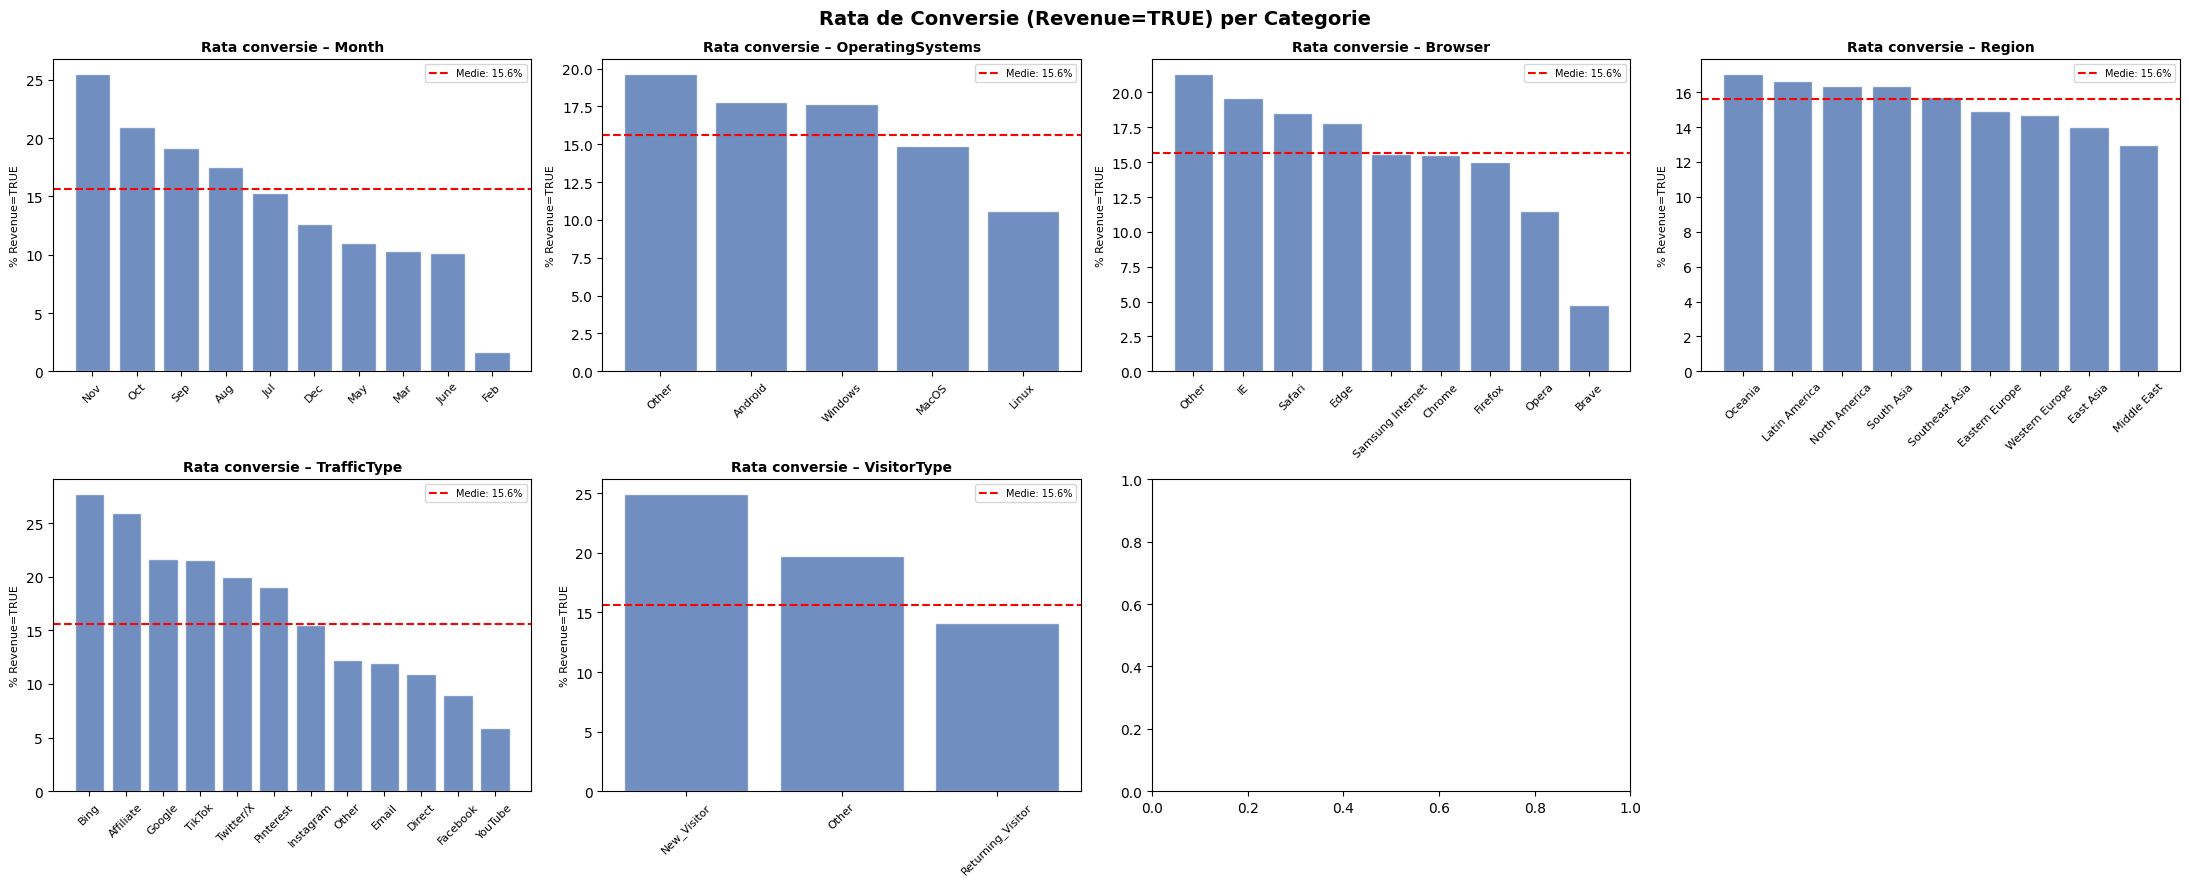

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Rata de Conversie (Revenue=TRUE) per Categorie',
             fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    ax = axes[i]
    conv = df.groupby(col)['Revenue'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(conv.index.astype(str), conv.values,
                  color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.axhline(df['Revenue'].mean() * 100, color='red', linestyle='--',
               linewidth=1.5, label=f'Medie: {df["Revenue"].mean()*100:.1f}%')
    ax.set_title(f'Rata conversie – {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('% Revenue=TRUE', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=7)
 
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

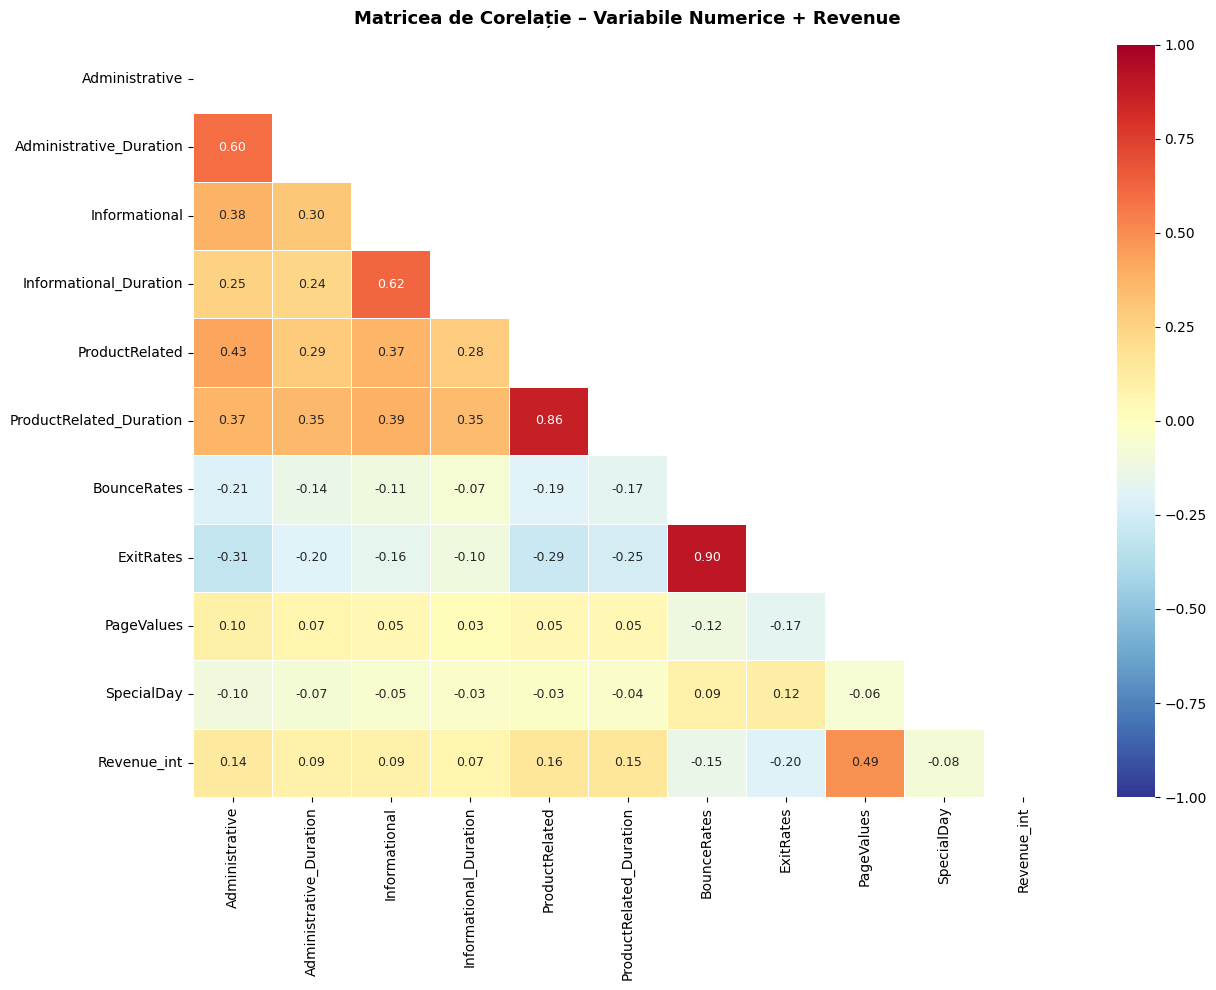

In [15]:
df_corr = df.copy()
df_corr['Revenue_int'] = df_corr['Revenue'].astype(int)
corr_matrix = df_corr[num_cols + ['Revenue_int']].corr()
 
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Matricea de Corelație – Variabile Numerice + Revenue',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

PageValues                 0.4919
ProductRelated             0.1560
ProductRelated_Duration    0.1501
Administrative             0.1363
Informational              0.0936
Administrative_Duration    0.0918
Informational_Duration     0.0694
SpecialDay                -0.0836
BounceRates               -0.1451
ExitRates                 -0.2043


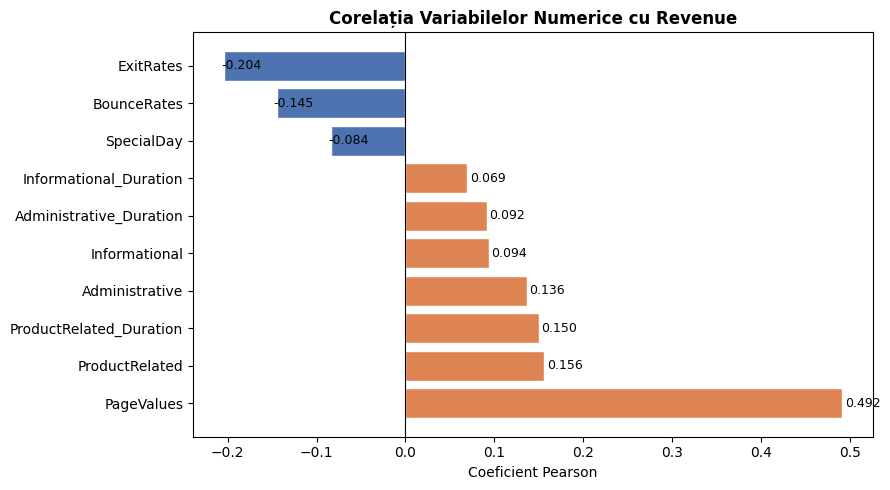

In [16]:
corr_target = corr_matrix['Revenue_int'].drop('Revenue_int').sort_values(ascending=False)
print(corr_target.round(4).to_string())
 
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#DD8452' if x > 0 else '#4C72B0' for x in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corelația Variabilelor Numerice cu Revenue', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficient Pearson')
for i, (name, val) in enumerate(zip(corr_target.index, corr_target.values)):
    ax.text(val + 0.003 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
median_pv_false = df[df['Revenue'] == False]['PageValues'].median()
median_pv_true  = df[df['Revenue'] == True]['PageValues'].median()
print(f"Mediana PageValues | Revenue=FALSE: {median_pv_false}")
print(f"Mediana PageValues | Revenue=TRUE : {median_pv_true:.2f}")

Mediana PageValues | Revenue=FALSE: 0.0
Mediana PageValues | Revenue=TRUE : 16.76


In [18]:
print("\n── PASUL 2: FLAGURI isZero ──")

# ProductRelated_Duration exclus — doar 5.2% zerouri, neglijabil
cols_zero_flag = [
    'BounceRates',              # 45.2% zerouri
    'PageValues',               # 77.6% zerouri
    'Administrative_Duration',  # 47.3% zerouri
    'Informational_Duration',   # 80.3% zerouri
]

print(f"  {'Variabilă':<30} {'% Zerouri':>10}  Decizie")
print(f"  {'-'*60}")
for col in df.select_dtypes(include=[np.number]).columns:
    pct = (df[col] == 0).mean() * 100
    if col in cols_zero_flag:
        df[f'{col}_isZero'] = (df[col] == 0).astype(int)
        print(f"  {col:<30} {pct:>9.1f}%  ✅ FLAG CREAT")
    elif col == 'ProductRelated_Duration':
        print(f"  {col:<30} {pct:>9.1f}%  ⏭️  IGNORAT (sub 20%)")


── PASUL 2: FLAGURI isZero ──
  Variabilă                       % Zerouri  Decizie
  ------------------------------------------------------------
  Administrative_Duration             47.3%  ✅ FLAG CREAT
  Informational_Duration              80.3%  ✅ FLAG CREAT
  ProductRelated_Duration              5.2%  ⏭️  IGNORAT (sub 20%)
  BounceRates                         45.2%  ✅ FLAG CREAT
  PageValues                          77.6%  ✅ FLAG CREAT


In [19]:
def discretize_nonzero(series, n_intervals=5, col_name=''):
    """
    Discretizare îmbunătățită față de quartile:
    - Zero → categorie separată 'Zero' (semantică distinctă)
    - Non-zero → n intervale EGALE pe domeniul non-zero
    - Limita superioară = percentila 95 → ultimul interval deschis (∞)
      absoarbe outlierii fără să distorsioneze distribuția
    - Codificare cu MIJLOCUL intervalului → conservă ordinea și distanțele
    
    Avantaj față de quartile: conservă distribuția originară și
    monotonia relației cu variabila obiectiv.
    """
    result  = pd.Series(['Zero'] * len(series), index=series.index, dtype=object)
    nonzero = series[series > 0]

    if len(nonzero) == 0:
        return result

    min_val = nonzero.min()
    max_val = nonzero.quantile(0.95)  # P95 → ultimul interval absoarbe top 5%
    step    = (max_val - min_val) / n_intervals

    # Construire margini intervale
    edges = [min_val + i * step for i in range(n_intervals)]
    edges.append(float('inf'))  # interval deschis la dreapta

    # Mijloacele intervalelor pentru codificare
    midpoints = []
    for i in range(len(edges) - 1):
        if edges[i+1] == float('inf'):
            mid = edges[i] + step / 2
        else:
            mid = (edges[i] + edges[i+1]) / 2
        midpoints.append(round(mid, 4))

    # Raport intervale
    print(f"\n  {col_name} (step={step:.4f}, P95={max_val:.4f}):")
    for i in range(len(edges) - 1):
        sup = '∞' if edges[i+1] == float('inf') else f'{edges[i+1]:.4f}'
        print(f"    [{edges[i]:.4f}, {sup}) → mijloc: {midpoints[i]}")

    # Aplicare
    for idx in nonzero.index:
        val = series[idx]
        for i in range(len(edges) - 1):
            in_last = (edges[i+1] == float('inf') and val >= edges[i])
            in_mid  = (edges[i] <= val < edges[i+1])
            if in_mid or in_last:
                result[idx] = str(midpoints[i])
                break

    return result

# Variabile de discretizat
disc_config = {
    'BounceRates':             5,
    'PageValues':              5,
    'ExitRates':               5,
    'ProductRelated_Duration': 5,
    'Administrative_Duration': 5,
}

disc_cols_created = []
for col, n_int in disc_config.items():
    new_col = f'{col}_disc'
    df[new_col] = discretize_nonzero(df[col], n_intervals=n_int, col_name=col)
    disc_cols_created.append(new_col)


  BounceRates (step=0.0400, P95=0.2000):
    [0.0000, 0.0400) → mijloc: 0.02
    [0.0400, 0.0800) → mijloc: 0.06
    [0.0800, 0.1200) → mijloc: 0.1
    [0.1200, 0.1600) → mijloc: 0.14
    [0.1600, ∞) → mijloc: 0.18

  PageValues (step=16.2372, P95=81.2240):
    [0.0380, 16.2752) → mijloc: 8.1566
    [16.2752, 32.5124) → mijloc: 24.3938
    [32.5124, 48.7496) → mijloc: 40.631
    [48.7496, 64.9868) → mijloc: 56.8682
    [64.9868, ∞) → mijloc: 73.1054

  ExitRates (step=0.0350, P95=0.1750):
    [0.0002, 0.0351) → mijloc: 0.0177
    [0.0351, 0.0701) → mijloc: 0.0526
    [0.0701, 0.1051) → mijloc: 0.0876
    [0.1051, 0.1400) → mijloc: 0.1226
    [0.1400, ∞) → mijloc: 0.1575

  ProductRelated_Duration (step=885.6880, P95=4428.9400):
    [0.5000, 886.1880) → mijloc: 443.344
    [886.1880, 1771.8760) → mijloc: 1329.032
    [1771.8760, 2657.5640) → mijloc: 2214.72
    [2657.5640, 3543.2520) → mijloc: 3100.408
    [3543.2520, ∞) → mijloc: 3986.096

  Administrative_Duration (step=101.6900, P95

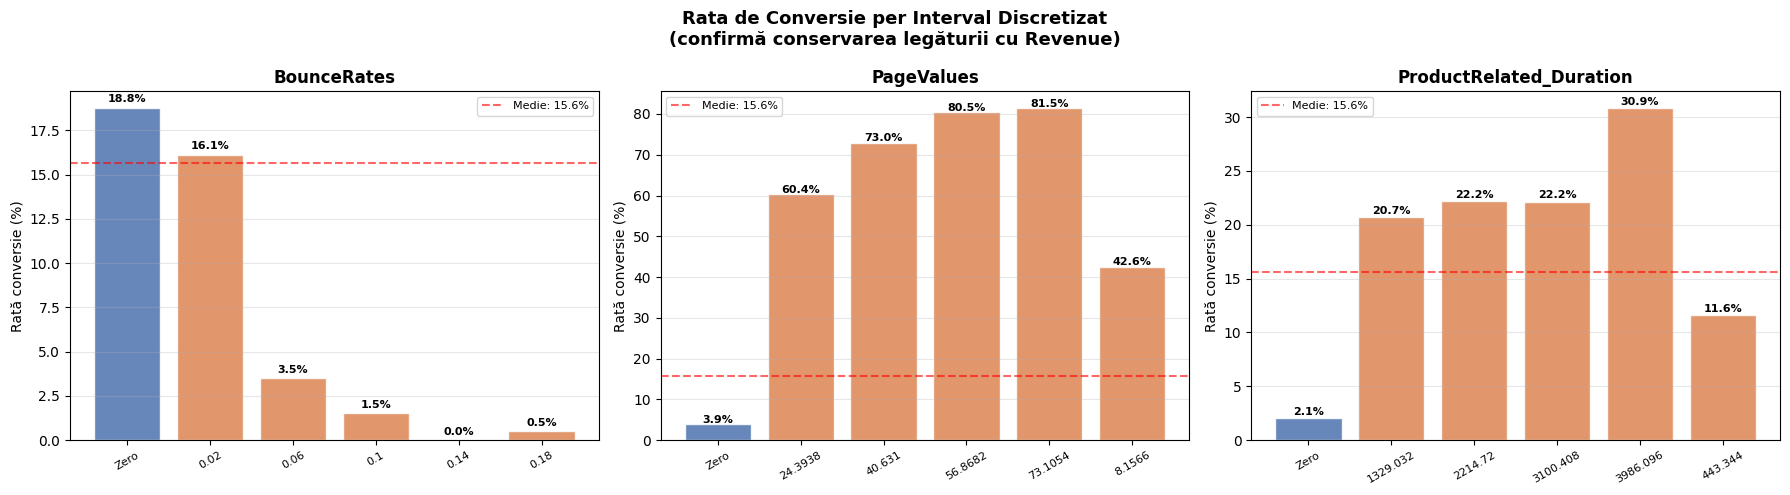

In [20]:
key_disc = ['BounceRates_disc', 'PageValues_disc', 'ProductRelated_Duration_disc']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rata de Conversie per Interval Discretizat\n'
             '(confirmă conservarea legăturii cu Revenue)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, key_disc):
    conv = df.groupby(col)['Revenue'].mean().sort_index() * 100

    # Sortare: Zero primul
    zero_val = conv.get('Zero', None)
    rest = conv.drop('Zero', errors='ignore').sort_index()
    if zero_val is not None:
        labels = ['Zero'] + rest.index.tolist()
        values = [zero_val] + rest.values.tolist()
    else:
        labels = rest.index.tolist()
        values = rest.values.tolist()

    colors = ['#4C72B0'] + ['#DD8452'] * (len(labels) - 1)
    bars = ax.bar(range(len(labels)), values, color=colors, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, fontsize=8)
    ax.set_title(col.replace('_disc', ''), fontweight='bold')
    ax.set_ylabel('Rată conversie (%)')
    ax.axhline(df['Revenue'].mean() * 100, color='red',
               linestyle='--', linewidth=1.5, alpha=0.6,
               label=f'Medie: {df["Revenue"].mean()*100:.1f}%')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
flag_cols = [c for c in df.columns if '_isZero' in c]
corr = df[flag_cols].corr().round(2)
print(corr.to_string())

# Confirmare că nu există colinearitate
max_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).max().max()
print(f"\n  Corelație maximă între flaguri: {max_corr:.2f}")
if max_corr < 0.5:
    print("Nicio colinearitate problematică — flagurile sunt independente")
else:
    print("Colinearitate detectată — verifică flagurile")

                                Administrative_Duration_isZero  Informational_Duration_isZero  BounceRates_isZero  PageValues_isZero
Administrative_Duration_isZero                            1.00                           0.30               -0.03               0.30
Informational_Duration_isZero                             0.30                           1.00                0.13               0.24
BounceRates_isZero                                       -0.03                           0.13                1.00               0.02
PageValues_isZero                                         0.30                           0.24                0.02               1.00

  Corelație maximă între flaguri: 0.30
Nicio colinearitate problematică — flagurile sunt independente


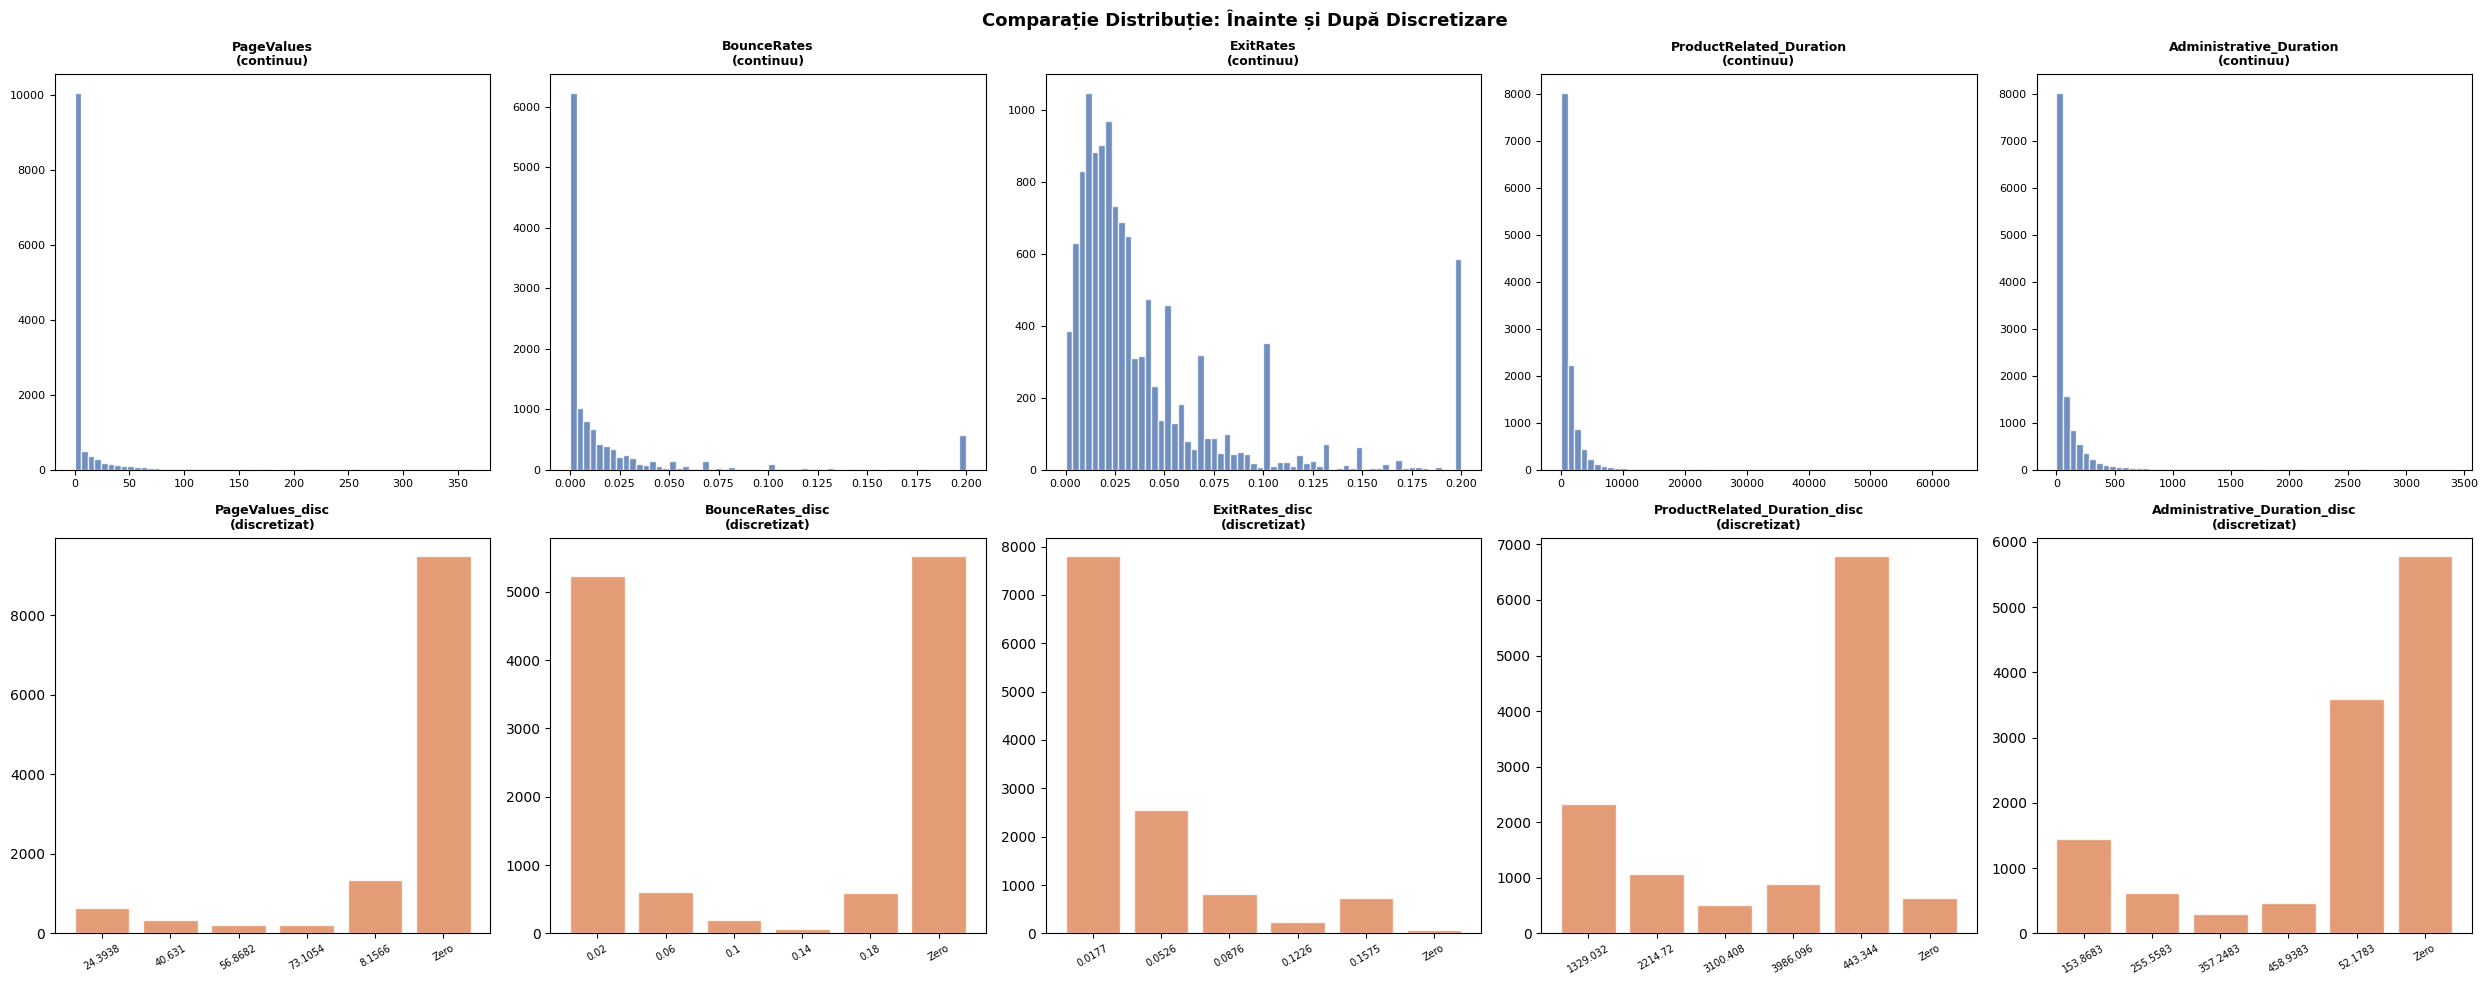

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle('Comparație Distribuție: Înainte și După Discretizare', fontsize=13, fontweight='bold')
 
orig_cols = ['PageValues', 'BounceRates', 'ExitRates',
             'ProductRelated_Duration', 'Administrative_Duration']
disc_cols = ['PageValues_disc', 'BounceRates_disc', 'ExitRates_disc',
             'ProductRelated_Duration_disc', 'Administrative_Duration_disc']
 
for i, (orig, disc) in enumerate(zip(orig_cols, disc_cols)):
    ax1 = axes[0][i]
    ax1.hist(df[orig].dropna(), bins=60, color='#4C72B0', alpha=0.8, edgecolor='white')
    ax1.set_title(f'{orig}\n(continuu)', fontsize=9, fontweight='bold')
    ax1.tick_params(labelsize=8)
 
    ax2 = axes[1][i]
    vc = df[disc].value_counts().sort_index()
    ax2.bar(range(len(vc)), vc.values, color='#DD8452', alpha=0.8, edgecolor='white')
    ax2.set_xticks(range(len(vc)))
    ax2.set_xticklabels(vc.index.tolist(), rotation=30, fontsize=7)
    ax2.set_title(f'{disc}\n(discretizat)', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.show()

In [24]:
df_final = df.copy()

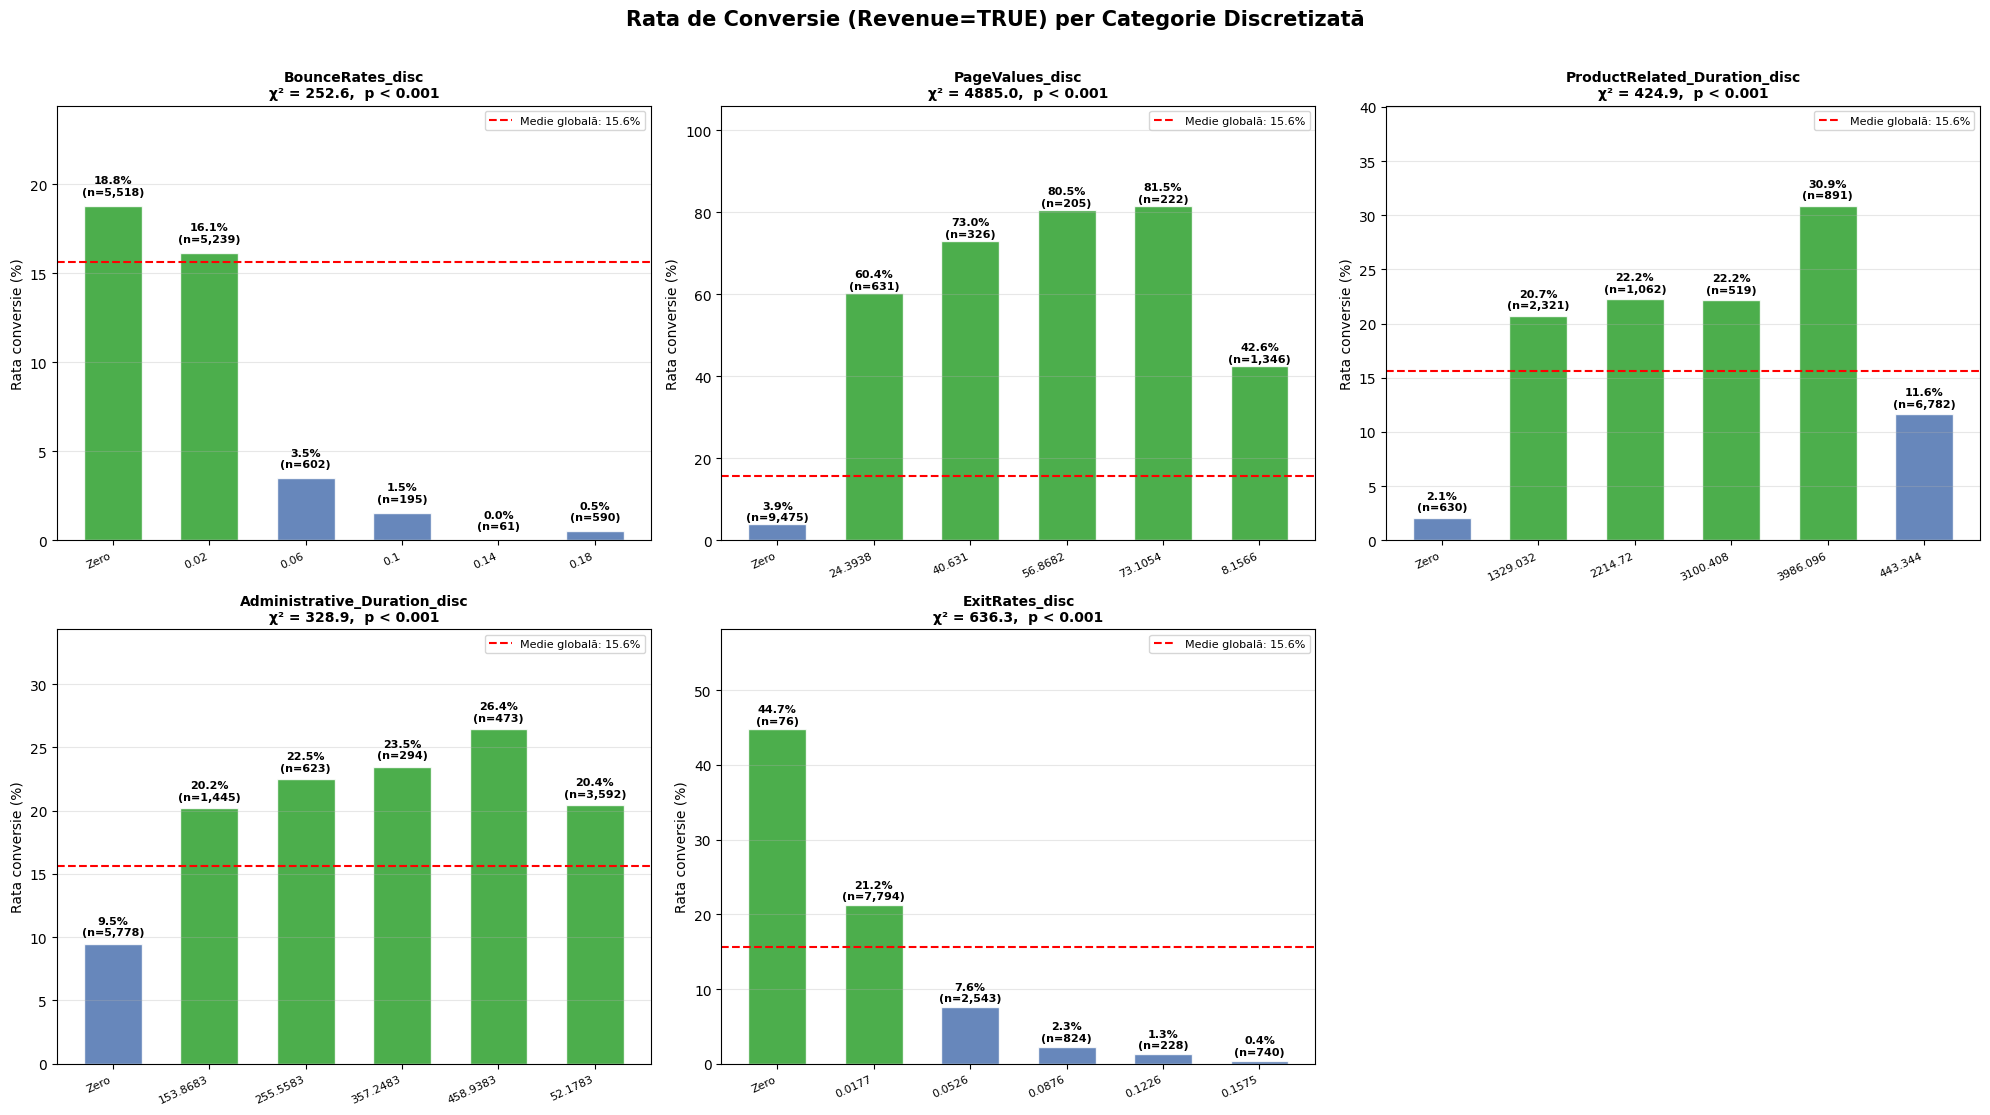

Salvat: conversie_per_categorie_disc.png


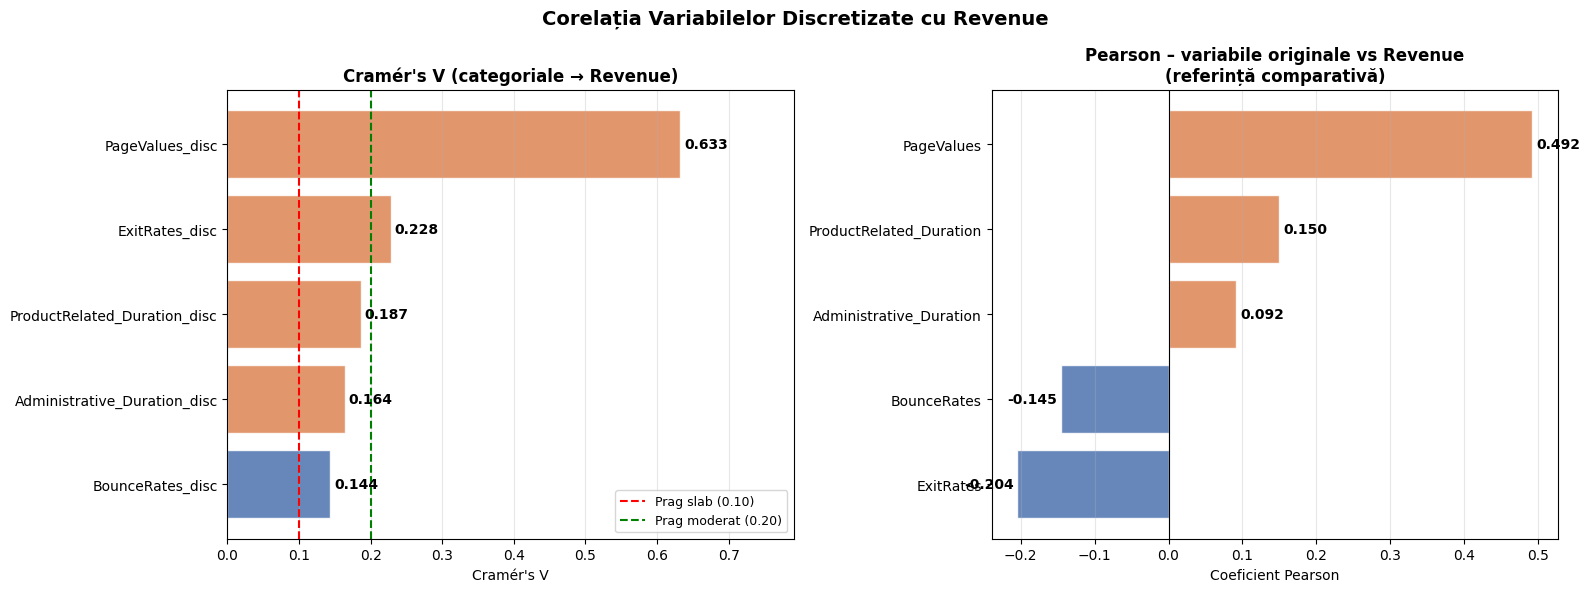

Salvat: corelatie_disc_revenue.png

── TABEL SUMAR: Asociere Variabile Discretizate cu Revenue ──

Variabilă                                        χ²      p-value   Cramér V Asociere
----------------------------------------------------------------------------------
BounceRates_disc                              252.6      < 0.001      0.144   Slabă
PageValues_disc                              4885.0      < 0.001      0.633   Puternică
ProductRelated_Duration_disc                  424.9      < 0.001      0.187   Moderată
Administrative_Duration_disc                  328.9      < 0.001      0.164   Moderată
ExitRates_disc                                636.3      < 0.001      0.228   Moderată


In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# Coloanele discretizate și originalele lor
disc_map = {
    'BounceRates_disc':                  'BounceRates',
    'PageValues_disc':                   'PageValues',
    'ProductRelated_Duration_disc':      'ProductRelated_Duration',
    'Administrative_Duration_disc':      'Administrative_Duration',
    'ExitRates_disc':                    'ExitRates'
}

disc_cols  = list(disc_map.keys())
orig_cols  = list(disc_map.values())

# Revenue ca int pentru corelare
df_final['Revenue_int'] = df_final['Revenue'].astype(int)

# ─────────────────────────────────────────────────────────
# GRAFIC 1: Rata de conversie per categorie (bara + linie medie)
# ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Rata de Conversie (Revenue=TRUE) per Categorie Discretizată',
             fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

medie_globala = df_final['Revenue_int'].mean() * 100

for i, disc_col in enumerate(disc_cols):
    ax = axes[i]

    # Rata de conversie și numărul de observații per categorie
    grp = df_final.groupby(disc_col, observed=True).agg(
        rata=('Revenue_int', 'mean'),
        n=('Revenue_int', 'count')
    ).reset_index()
    grp['rata_pct'] = grp['rata'] * 100

    # Sortare după valoarea categoriei (Zero primul dacă există)
    try:
        grp[disc_col] = grp[disc_col].astype(str)
        zero_rows  = grp[grp[disc_col] == 'Zero']
        rest_rows  = grp[grp[disc_col] != 'Zero'].sort_values(disc_col)
        grp = pd.concat([zero_rows, rest_rows]).reset_index(drop=True)
    except Exception:
        grp = grp.sort_values(disc_col).reset_index(drop=True)

    # Culori: verde dacă > medie globală, albastru dacă sub
    culori = ['#2ca02c' if v >= medie_globala else '#4C72B0'
              for v in grp['rata_pct']]

    bars = ax.bar(range(len(grp)), grp['rata_pct'],
                  color=culori, edgecolor='white', alpha=0.85, width=0.6)

    # Linie medie globală
    ax.axhline(medie_globala, color='red', linestyle='--',
               linewidth=1.5, label=f'Medie globală: {medie_globala:.1f}%')

    # Etichete pe bare: % conversie + n observații
    for j, (bar, row) in enumerate(zip(bars, grp.itertuples())):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{row.rata_pct:.1f}%\n(n={row.n:,})',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Chi-Square test
    ct = pd.crosstab(df_final[disc_col], df_final['Revenue_int'])
    chi2, p, dof, _ = chi2_contingency(ct)
    p_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'

    ax.set_title(f'{disc_col}\nχ² = {chi2:.1f},  {p_str}',
                 fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp[disc_col].tolist(), rotation=25,
                       ha='right', fontsize=8)
    ax.set_ylabel('Rata conversie (%)')
    ax.set_ylim(0, grp['rata_pct'].max() * 1.30)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../../outputs/conversie_per_categorie_disc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: conversie_per_categorie_disc.png")


# ─────────────────────────────────────────────────────────
# GRAFIC 2: Corelația variabilelor discretizate cu Revenue
# (Cramér's V — potrivit pentru categoriale)
# ─────────────────────────────────────────────────────────

def cramers_v(col, target):
    ct = pd.crosstab(col, target)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Corelația Variabilelor Discretizate cu Revenue",
             fontsize=14, fontweight='bold')

# ── Stânga: Cramér's V pentru disc ──
cv_vals = {}
for disc_col in disc_cols:
    cv_vals[disc_col] = cramers_v(df_final[disc_col].astype(str),
                                   df_final['Revenue_int'])

cv_series = pd.Series(cv_vals).sort_values(ascending=True)

culori_cv = ['#DD8452' if v >= 0.15 else '#4C72B0' for v in cv_series.values]
bars = axes[0].barh(cv_series.index, cv_series.values,
                     color=culori_cv, edgecolor='white', alpha=0.85)
axes[0].axvline(0.10, color='red', linestyle='--',
                linewidth=1.5, label='Prag slab (0.10)')
axes[0].axvline(0.20, color='green', linestyle='--',
                linewidth=1.5, label='Prag moderat (0.20)')
for bar, val in zip(bars, cv_series.values):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel("Cramér's V")
axes[0].set_title("Cramér's V (categoriale → Revenue)", fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, cv_series.max() * 1.25)
axes[0].grid(axis='x', alpha=0.3)

# ── Dreapta: Pearson pe originalele numerice (pentru comparație) ──
corr_orig = df_final[orig_cols + ['Revenue_int']].corr()['Revenue_int'].drop('Revenue_int')
corr_orig = corr_orig.sort_values(ascending=True)

culori_p = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_orig.values]
bars2 = axes[1].barh(corr_orig.index, corr_orig.values,
                      color=culori_p, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars2, corr_orig.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', ha=ha,
                 fontsize=10, fontweight='bold')
axes[1].set_xlabel("Coeficient Pearson")
axes[1].set_title("Pearson – variabile originale vs Revenue\n(referință comparativă)",
                   fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/corelatie_disc_revenue.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: corelatie_disc_revenue.png")


# ─────────────────────────────────────────────────────────
# TABEL SUMAR — Chi-Square + Cramér's V pentru toate disc
# ─────────────────────────────────────────────────────────

print("\n── TABEL SUMAR: Asociere Variabile Discretizate cu Revenue ──\n")
print(f"{'Variabilă':<40} {'χ²':>10} {'p-value':>12} {'Cramér V':>10} {'Asociere'}")
print("-" * 82)

for disc_col in disc_cols:
    ct    = pd.crosstab(df_final[disc_col].astype(str), df_final['Revenue_int'])
    chi2, p, _, _ = chi2_contingency(ct)
    cv    = cramers_v(df_final[disc_col].astype(str), df_final['Revenue_int'])
    nivel = 'Puternică' if cv >= 0.25 else ('Moderată' if cv >= 0.15 else 'Slabă')
    p_str = '< 0.001' if p < 0.001 else f'{p:.3f}'
    print(f"{disc_col:<40} {chi2:>10.1f} {p_str:>12} {cv:>10.3f} {'  ' + nivel}")

In [ ]:
counts = df['Revenue'].value_counts()
pcts = df['Revenue'].value_counts(normalize=True) * 100
 
print(f"Clasa FALSE (nu cumpără): {counts[False]:>6,} -> {pcts[False]:.2f}%")
print(f"Clasa TRUE (cumpără): {counts[True]:>6,} -> {pcts[True]:.2f}%")
print(f"Raport dezechilibru : {counts[False]/counts[True]:.1f} : 1")

Clasa FALSE (nu cumpără): 10,297 -> 84.37%
Clasa TRUE (cumpără):  1,908 -> 15.63%
Raport dezechilibru : 5.4 : 1


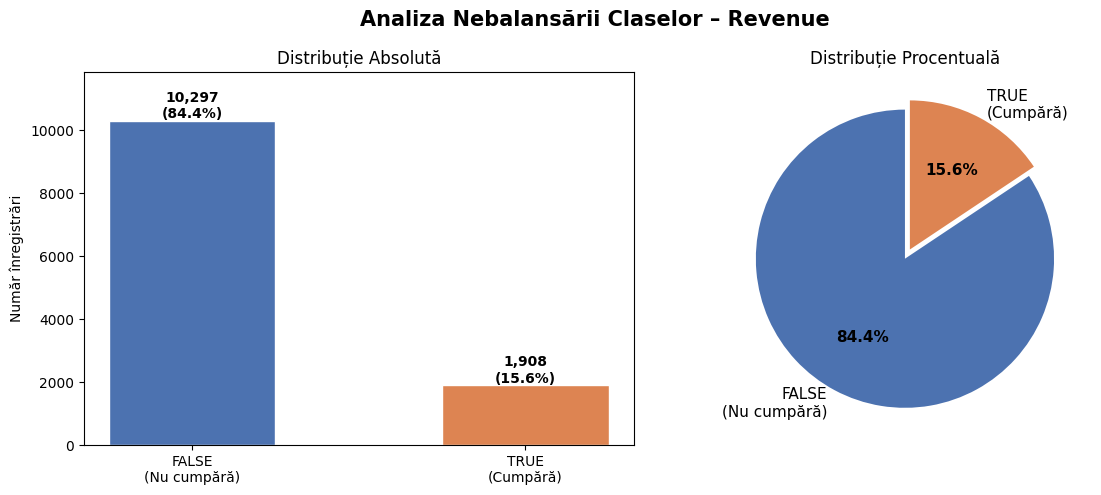

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analiza Nebalansării Claselor – Revenue', fontsize=15, fontweight='bold')
colors = ['#4C72B0', '#DD8452']

axes[0].bar(['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
            [counts[False], counts[True]],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribuție Absolută', fontsize=12)
axes[0].set_ylabel('Număr înregistrări')
for i, (v, p) in enumerate(zip([counts[False], counts[True]], [pcts[False], pcts[True]])):
    axes[0].text(i, v + 80, f'{v:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylim(0, counts[False] * 1.15)

wedges, texts, autotexts = axes[1].pie(
    [counts[False], counts[True]],
    labels=['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.07),
    textprops={'fontsize': 11}
)
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
axes[1].set_title('Distribuție Procentuală', fontsize=12)
 
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTENC

# ─────────────────────────────────────────────────────────
# PASUL 3: ENCODING — toate coloanele non-numerice
# (categoriale originale + disc + Weekend + Revenue)
# ─────────────────────────────────────────────────────────

df_encoded = df_final.copy()

le_dict = {}

# Categoriale originale (sunt deja str după recoding)
cat_cols_orig = ['Month', 'OperatingSystems', 'Browser',
                 'Region', 'TrafficType', 'VisitorType']

# Coloane discretizate (sunt string: 'Zero', '0.02' etc.)
disc_cols = [col for col in df_encoded.columns if '_disc' in col]

# Weekend și Revenue → int
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

# Label Encoding pe toate string-urile
for col in cat_cols_orig + disc_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le
    print(f"  Encoded: {col} → {list(le.classes_)[:6]}{'...' if len(le.classes_) > 6 else ''}")

print(f"\nTipuri după encoding:")
print(df_encoded.dtypes)
print(f"\nValori lipsă: {df_encoded.isnull().sum().sum()}")

# ─────────────────────────────────────────────────────────
# PASUL 4: SMOTE-NC
# Coloanele categoriale = originale + disc + isZero flags + Weekend
# ─────────────────────────────────────────────────────────

X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Coloanele care NU se interpolează (categoriale/binare/ordinale)
categorical_cols = (
    cat_cols_orig +
    disc_cols +
    [col for col in X.columns if '_isZero' in col] +
    ['Weekend']
)

# Indicii lor în X
categorical_idx = [list(X.columns).index(col)
                   for col in categorical_cols if col in X.columns]

print(f"\nColoane categoriale pentru SMOTE-NC ({len(categorical_idx)}):")
for idx in categorical_idx:
    print(f"  [{idx}] {X.columns[idx]}")

print(f"\nColoane numerice (interpolare normală):")
numeric_cols = [col for col in X.columns if col not in categorical_cols]
for col in numeric_cols:
    print(f"  {col}")

# Balansare
smote_nc = SMOTENC(
    categorical_features=categorical_idx,
    sampling_strategy=0.5,
    random_state=7,
    k_neighbors=5
)

X_res, y_res = smote_nc.fit_resample(X, y)

print(f"\nÎnainte de SMOTE-NC: {dict(pd.Series(y).value_counts())}")
print(f"După SMOTE-NC      : {dict(pd.Series(y_res).value_counts())}")
print(f"Raport             : {pd.Series(y_res).value_counts()[1] / pd.Series(y_res).value_counts()[0]:.2f}")
print(f"Total înregistrări : {len(y_res):,}")

# ─────────────────────────────────────────────────────────
# PASUL 5: Reconstruire și salvare df_final
# ─────────────────────────────────────────────────────────

df_final_v2 = pd.DataFrame(X_res, columns=X.columns)
df_final_v2['Revenue'] = y_res

print(f"\nShape final: {df_final_v2.shape}")
print(f"Valori lipsă: {df_final_v2.isnull().sum().sum()}")
print(f"\nColoane:")
print(df_final_v2.columns.tolist())

df_final_v2.to_csv('../../data/processed/online_shoppers_final_v2.csv', index=False)
print("\n✅ Salvat: online_shoppers_final_v2.csv")

  Encoded: Month → ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar']...
  Encoded: OperatingSystems → ['Android', 'Linux', 'MacOS', 'Other', 'Windows']
  Encoded: Browser → ['Brave', 'Chrome', 'Edge', 'Firefox', 'IE', 'Opera']...
  Encoded: Region → ['East Asia', 'Eastern Europe', 'Latin America', 'Middle East', 'North America', 'Oceania']...
  Encoded: TrafficType → ['Affiliate', 'Bing', 'Direct', 'Email', 'Facebook', 'Google']...
  Encoded: VisitorType → ['New_Visitor', 'Other', 'Returning_Visitor']
  Encoded: BounceRates_disc → ['0.02', '0.06', '0.1', '0.14', '0.18', 'Zero']
  Encoded: PageValues_disc → ['24.3938', '40.631', '56.8682', '73.1054', '8.1566', 'Zero']
  Encoded: ExitRates_disc → ['0.0177', '0.0526', '0.0876', '0.1226', '0.1575', 'Zero']
  Encoded: ProductRelated_Duration_disc → ['1329.032', '2214.72', '3100.408', '3986.096', '443.344', 'Zero']
  Encoded: Administrative_Duration_disc → ['153.8683', '255.5583', '357.2483', '458.9383', '52.1783', 'Zero']

Tipuri după encoding:
A

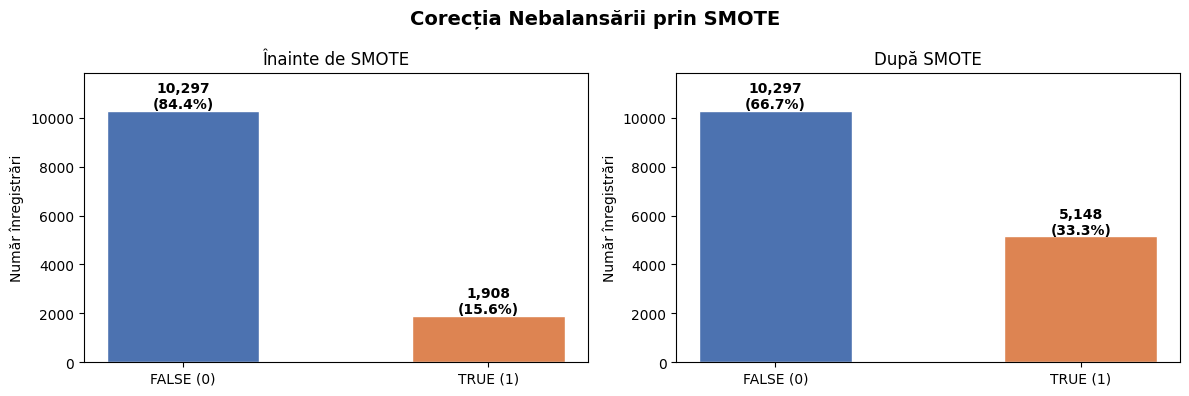

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Corecția Nebalansării prin SMOTE', fontsize=14, fontweight='bold')
 
before = pd.Series(y).value_counts()
after  = pd.Series(y_res).value_counts()
 
for ax, data, title in zip(axes, [before, after], ['Înainte de SMOTE', 'După SMOTE']):
    ax.bar(['FALSE (0)', 'TRUE (1)'], [data[0], data[1]], color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Număr înregistrări')
    for i, v in enumerate([data[0], data[1]]):
        pct = v / data.sum() * 100
        ax.text(i, v + 100, f'{v:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(before[0], after[0]) * 1.15)
 
plt.tight_layout()
plt.show()